# 2. ETL y análisis exploratorio (EDA)

## Propósito

Cargar el dataset OHLCV de INTC, aplicar limpieza básica, persistir la
versión procesada y producir el análisis exploratorio que justifique la
elección del problema y documente los hechos estilizados relevantes.

## Conexión con el capítulo anterior

En el capítulo 1 definimos el problema (regresión de $\sigma_{t+1}$ y
clasificación de $\rho_{t+1}$, ambos a horizonte de un día) y la fuente
de datos. Aquí materializamos esa fuente como un objeto tabular limpio
y reproducible.

## 2.1 Carga del dataset

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data_loader import load_intc
from src.viz import set_style, savefig, PALETTE
from src.io_utils import save_parquet

set_style()

df = load_intc()
print(f"Filas cargadas : {len(df):,}")
print(f"Rango temporal : {df['date'].min().date()} → {df['date'].max().date()}")
df.head()

Filas cargadas : 7,022
Rango temporal : 1990-01-02 → 2017-11-10


,date,open,high,low,close,volume
0,1990-01-02,0.8579,0.8982,0.8499,0.8982,79600273
1,1990-01-03,0.8982,0.9061,0.8740,0.8740,86671242
2,1990-01-04,0.8820,0.8982,0.8579,0.8904,72928342
3,1990-01-05,0.8904,0.8982,0.8820,0.8820,46184758
4,1990-01-08,0.8904,0.9061,0.8820,0.8982,54001929


**Interpretación.** El loader devuelve un DataFrame ordenado
cronológicamente, sin valores nulos en `close`, con las seis columnas
OHLCV. El rango temporal cubre más de tres décadas — suficientes para
ver múltiples regímenes de volatilidad.

## 2.2 Limpieza e integridad

In [2]:
# 2.2.1 Conteo de NaN
print("Valores NaN por columna:")
print(df.isna().sum())
print()

# 2.2.2 Continuidad de fechas hábiles
date_diff = df["date"].diff().dt.days.dropna()
print(f"Saltos entre fechas (días calendario):")
print(date_diff.describe())
print()

# 2.2.3 Coherencia OHLC: high >= max(open, close), low <= min(open, close)
bad_high = (df["high"] < df[["open", "close"]].max(axis=1)).sum()
bad_low = (df["low"] > df[["open", "close"]].min(axis=1)).sum()
print(f"Filas con high < max(open, close) : {bad_high}")
print(f"Filas con low  > min(open, close) : {bad_low}")

Valores NaN por columna:
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Saltos entre fechas (días calendario):
count    7021.000000
mean        1.449081
std         0.876005
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         7.000000
Name: date, dtype: float64

Filas con high < max(open, close) : 0
Filas con low  > min(open, close) : 0


**Interpretación.** Las verificaciones de integridad cubren los tres
problemas clásicos de series OHLCV: nulos, discontinuidades temporales
inesperadas y violaciones de la relación lógica entre máximo, mínimo,
apertura y cierre. La distribución de saltos entre fechas debe
concentrarse en 1 día (sesión a sesión) con valores de 3 cuando hay fin
de semana, y ocasionalmente 4+ cuando hay festivos.

## 2.3 Persistencia del dataset limpio

In [3]:
config.ensure_dirs()
save_parquet(df, config.PROCESSED_FILE)
print(f"Guardado en: {config.PROCESSED_FILE.relative_to(config.PROJECT_ROOT)}")
print(f"Tamaño: {config.PROCESSED_FILE.stat().st_size / 1024:.1f} KB")

Guardado en: data/processed/intc_clean.parquet
Tamaño: 234.4 KB


## 2.4 Serie de precios

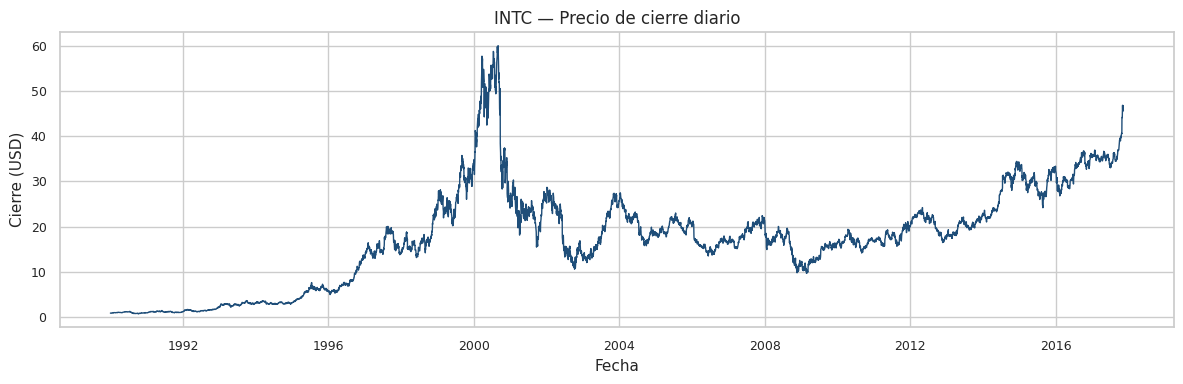

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["close"], color=PALETTE["primary"], linewidth=1)
ax.set_title("INTC — Precio de cierre diario")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cierre (USD)")
savefig(config.FIGURES_DIR / "02_close_price.png", fig)
plt.show()

**Interpretación.** La serie de precios muestra el ciclo clásico de
INTC: crecimiento sostenido durante los 90, pico de la burbuja .com a
principios de los 2000, corrección prolongada, recuperación gradual y
volatilidad reciente del sector semiconductor. Estos cambios de régimen
en precio se traducen, como veremos, en cambios de régimen en
volatilidad.

## 2.5 Log-retornos

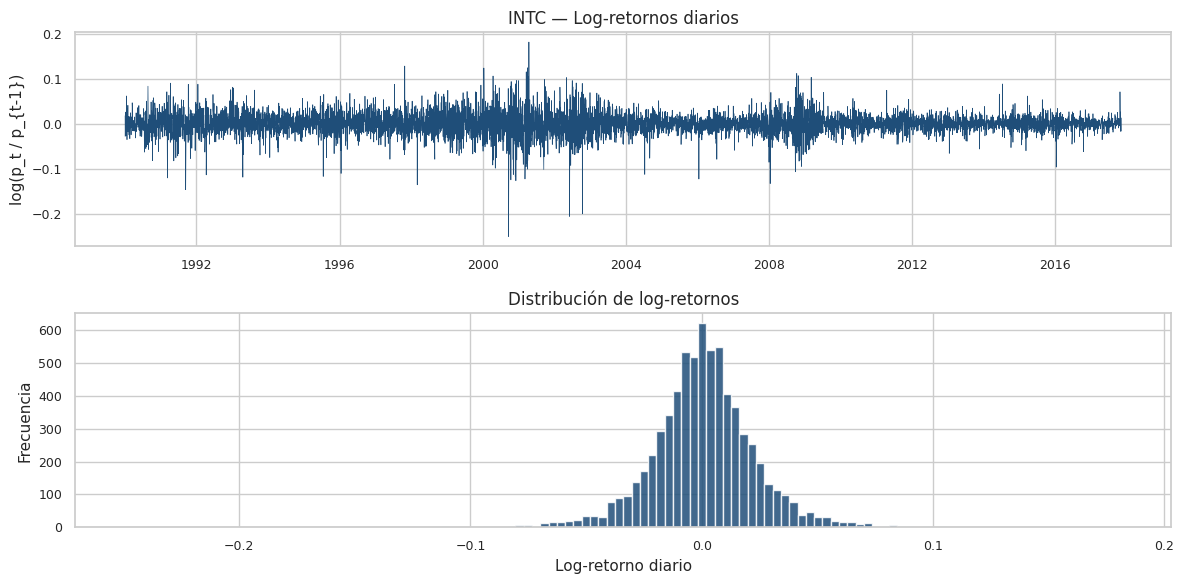

count    7021.000000
mean        0.000559
std         0.024027
min        -0.249342
25%        -0.011470
50%         0.000279
75%         0.012924
max         0.181532
Name: log_return, dtype: float64

Asimetría : -0.3921
Curtosis  : 6.5414


In [5]:
df["log_return"] = np.log(df["close"] / df["close"].shift(1))

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(df["date"], df["log_return"], color=PALETTE["primary"], linewidth=0.5)
axes[0].set_title("INTC — Log-retornos diarios")
axes[0].set_ylabel("log(p_t / p_{t-1})")
axes[0].set_xlabel("")

axes[1].hist(df["log_return"].dropna(), bins=120, color=PALETTE["primary"], alpha=0.85)
axes[1].set_title("Distribución de log-retornos")
axes[1].set_xlabel("Log-retorno diario")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
savefig(config.FIGURES_DIR / "02_log_returns.png", fig)
plt.show()

print(df["log_return"].describe())
print(f"\nAsimetría : {df['log_return'].skew():.4f}")
print(f"Curtosis  : {df['log_return'].kurt():.4f}")

**Interpretación.** Tres hechos estilizados quedan visualmente claros:

1. **Heterocedasticidad.** Hay períodos densos (alta volatilidad) y
 períodos calmos (baja volatilidad). Esto es el clustering que motiva
 GARCH/HAR-RV y todo el aparato de modelado de volatilidad.
2. **Colas pesadas.** La curtosis empírica es muy superior a 3 (la de
 una normal), indicando colas pesadas — eventos extremos son más
 frecuentes de lo que una distribución gaussiana predeciría.
3. **Asimetría ligeramente negativa.** Es típico de equities: caídas
 grandes son algo más frecuentes que subidas grandes equivalentes.

Estos hechos justifican usar la volatilidad realizada como target
predecible — su componente persistente domina sobre el ruido.

## 2.6 Volatilidad realizada

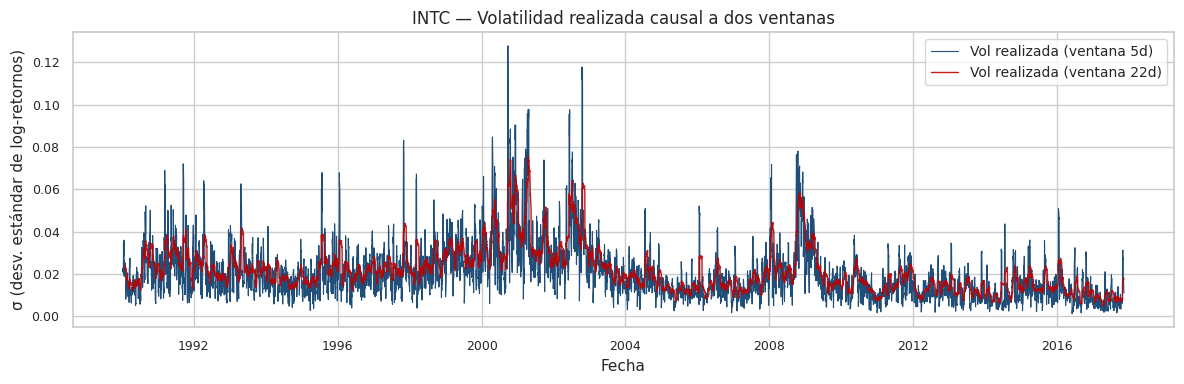

In [6]:
df["vol_5d"] = df["log_return"].rolling(5, min_periods=5).std()
df["vol_22d"] = df["log_return"].rolling(22, min_periods=22).std()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["vol_5d"], color=PALETTE["primary"], linewidth=0.8,
        label="Vol realizada (ventana 5d)")
ax.plot(df["date"], df["vol_22d"], color=PALETTE["secondary"], linewidth=1.0,
        label="Vol realizada (ventana 22d)", alpha=0.9)
ax.set_title("INTC — Volatilidad realizada causal a dos ventanas")
ax.set_xlabel("Fecha")
ax.set_ylabel("σ (desv. estándar de log-retornos)")
ax.legend()
savefig(config.FIGURES_DIR / "02_realized_volatility.png", fig)
plt.show()

**Interpretación.** La volatilidad realizada exhibe persistencia: los
picos coinciden con eventos macro conocidos (.com bust 2000-2002,
crisis financiera 2008-2009, COVID-19 marzo 2020). La serie de 22 días
suaviza el ruido y revela mejor los regímenes; la de 5 días captura
cambios rápidos. En el modelado base usamos $w=5$ porque mantiene la
señal sin sobre-suavizar el clustering reciente que queremos
pronosticar.

## 2.7 Autocorrelación de retornos y de volatilidad

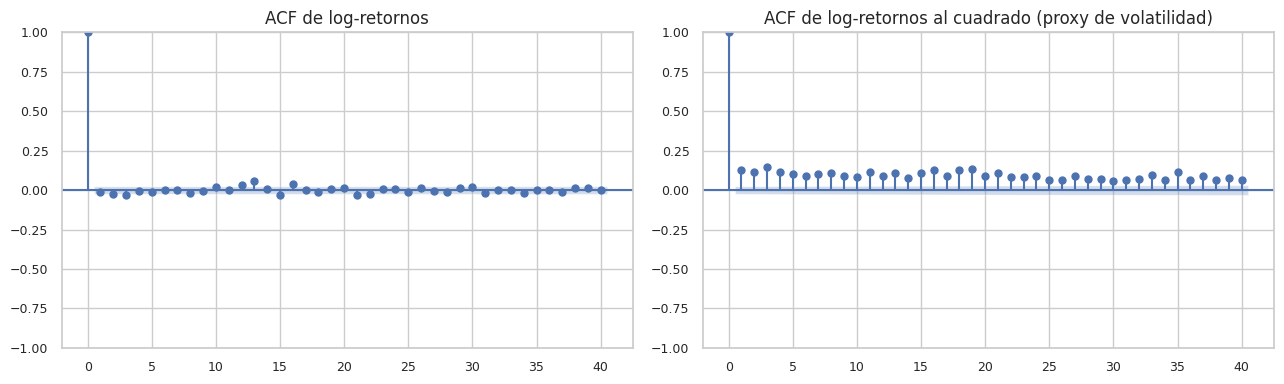

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df["log_return"].dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF de log-retornos")
plot_acf(df["log_return"].dropna().pow(2), lags=40, ax=axes[1])
axes[1].set_title("ACF de log-retornos al cuadrado (proxy de volatilidad)")
savefig(config.FIGURES_DIR / "02_acf_returns_vs_vol.png", fig)
plt.show()

**Interpretación.** Este es uno de los gráficos más importantes del
proyecto. Los **retornos** no muestran autocorrelación significativa
(consistente con eficiencia débil de mercado), pero los retornos al
cuadrado — proxy de la magnitud — muestran autocorrelación positiva y
persistente en muchos lags. Esto **valida empíricamente** la hipótesis
de que la volatilidad es pronosticable, mientras que el signo del
retorno no lo es. Es la base teórica que justifica que nuestro proyecto
modele $\sigma_{t+1}$ y no $r_{t+1}$.

## 2.8 Volumen

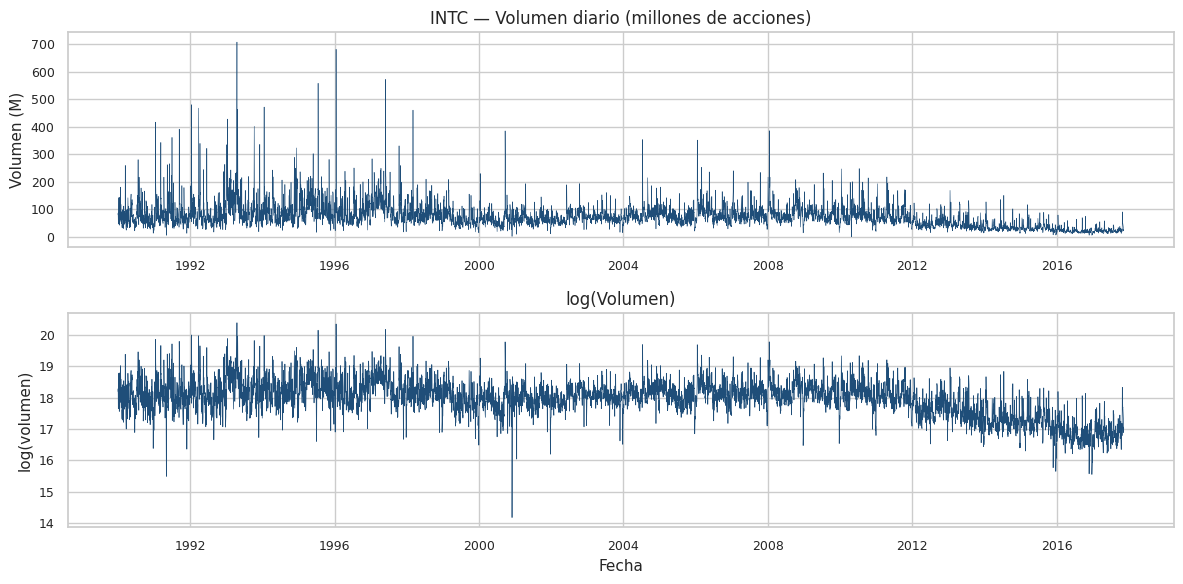

In [8]:
df["log_volume"] = np.log(df["volume"].replace(0, np.nan))

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(df["date"], df["volume"] / 1e6, color=PALETTE["primary"], linewidth=0.4)
axes[0].set_title("INTC — Volumen diario (millones de acciones)")
axes[0].set_ylabel("Volumen (M)")
axes[1].plot(df["date"], df["log_volume"], color=PALETTE["primary"], linewidth=0.5)
axes[1].set_title("log(Volumen)")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("log(volumen)")
plt.tight_layout()
savefig(config.FIGURES_DIR / "02_volume.png", fig)
plt.show()

**Interpretación.** El volumen presenta saltos estructurales claros
(particularmente en torno a desdoblamientos y eventos corporativos) y
una tendencia decreciente en años recientes, consistente con el
cambio en la base accionaria del sector tech. Trabajamos con
`log(volume)` y con un ratio `volume / volume.rolling(20).mean()` como
features, para que el modelo capture sorpresas de volumen relativas y
no niveles absolutos que varían con el tiempo.

## 2.9 Cierre del capítulo y conexión con el capítulo 3

El dataset está limpio, validado, persistido y visualmente
caracterizado. Los hallazgos clave que importan para el modelado son:

- La volatilidad de INTC tiene clustering fuerte y predecible (ACF de
 retornos al cuadrado significativa).
- Las colas son pesadas — los modelos deben ser robustos a *outliers*.
- Múltiples regímenes a lo largo del tiempo (crisis vs calma).
- Volumen con cambios estructurales — usar transformaciones relativas.

En el **capítulo 3** construimos las ~30 features causales y los dos
targets (`target_vol` y `target_regime`), aplicamos el split temporal
70/15/15 y persistimos los conjuntos `train/val/test` para los
notebooks de modelado. Allí también ejecutamos los tests anti-leakage
que blindan la pipeline.